     SEM 1  SEM 2  SEM 3  SEM 4  SEM 5
0     6.60   7.60   6.90   7.22   7.08
1     7.77   7.22   7.00   7.90   7.47
2     6.90   6.00   7.12   7.54   6.89
3     5.50   6.60   6.70   6.50   6.33
4     7.20   6.00   7.21   7.70   7.03
..     ...    ...    ...    ...    ...
374   0.10   0.10   0.20   0.14   0.14
375   0.10   0.10   0.20   0.14   0.14
376   0.10   0.10   0.20   0.14   0.14
377   0.10   0.10   0.20   0.14   0.14
378   0.10   0.10   0.20   0.14   0.14

[379 rows x 5 columns]
Shape : (379, 5)

Missing Values
 SEM 1    0
SEM 2    0
SEM 3    0
SEM 4    0
SEM 5    0
dtype: int64

Statistics
             SEM 1       SEM 2       SEM 3       SEM 4       SEM 5
count  379.000000  379.000000  379.000000  379.000000  379.000000
mean     5.908707    6.015858    6.103852    6.167546    6.050765
std      3.147572    3.139440    3.078922    3.131259    3.091451
min      0.100000    0.100000    0.130000    0.120000    0.140000
25%      4.080000    4.275000    4.870000    4.990000    4.2900

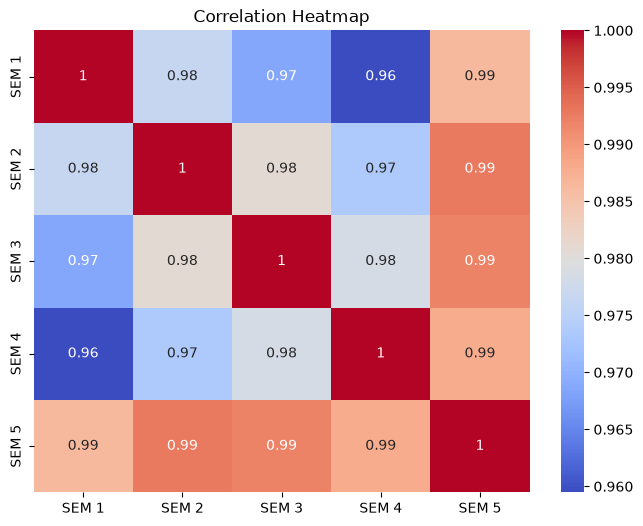

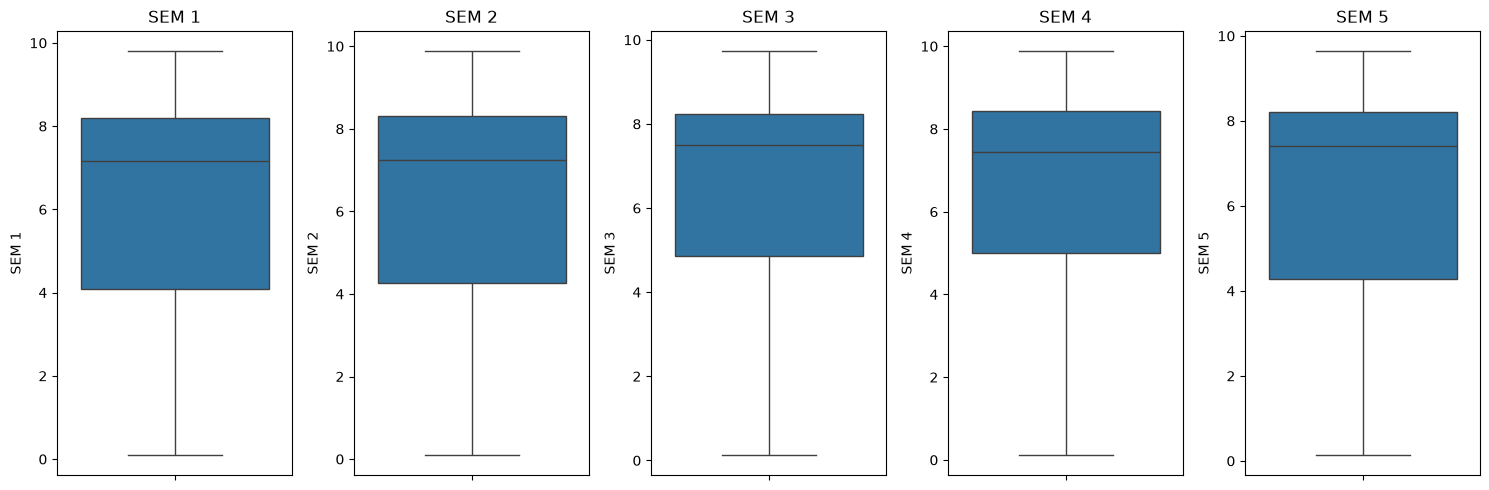


Best Feature : SEM 2

Simple Linear Regression
Equation : y = 0.17 + 0.98 * SEM 2
MAE : 0.24539275272591357
MSE : 0.11749088625729903
RMSE : 0.3427694360022478
R2 Score : 0.9887037961166778


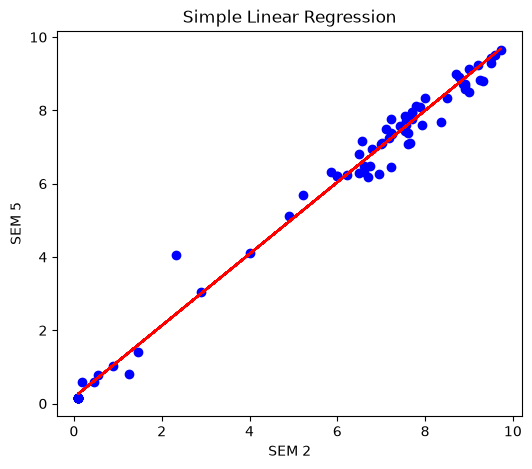


Multiple Linear Regression
Intercept : 0.0035713111292468014
Coefficients : [0.24985026 0.25024859 0.2499377  0.24966539]
MAE : 0.0023391696650218027
MSE : 7.162756055515345e-06
RMSE : 0.0026763325756556013
R2 Score : 0.9999993113342205


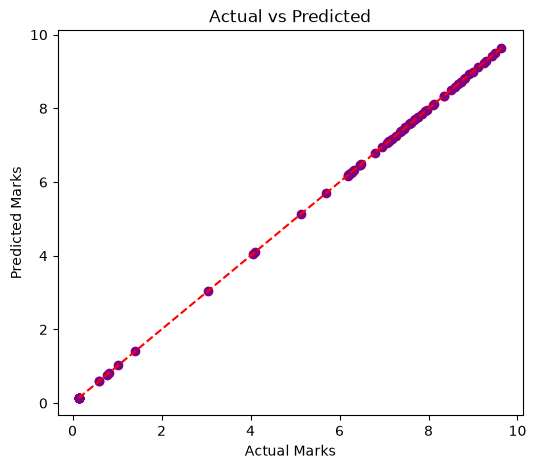

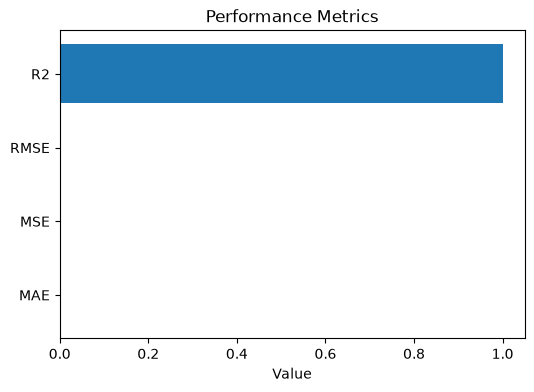


Enter Semester Marks


SEM 1:  7.5
SEM 2:  7.78
SEM 3:  7.4
SEM 4:  7.5



Predicted SEM 5 Marks : 7.55


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
df=pd.read_csv("cgpaPRED.csv")
print(df)


print("Shape :", df.shape)
print("\nMissing Values\n", df.isnull().sum())
print("\nStatistics\n", df.describe())


plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


plt.figure(figsize=(15,5))
for i, col in enumerate(df.columns):
    plt.subplot(1,5,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

X = df[["SEM 1","SEM 2","SEM 3","SEM 4"]]
y = df["SEM 5"]

best_feature = X.corrwith(y).abs().idxmax()
print("\nBest Feature :", best_feature)

X_simple = df[[best_feature]]

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

pred = simple_model.predict(X_test)

print("\nSimple Linear Regression")
print("Equation : y =", round(simple_model.intercept_,2), "+",
      round(simple_model.coef_[0],2), "*", best_feature)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

# Scatter Plot
plt.figure(figsize=(6,5))
plt.scatter(X_test, y_test, color="blue")
plt.plot(X_test, pred, color="red")
plt.xlabel(best_feature)
plt.ylabel("SEM 5")
plt.title("Simple Linear Regression")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

pred = multi_model.predict(X_test)

print("\nMultiple Linear Regression")
print("Intercept :", multi_model.intercept_)
print("Coefficients :", multi_model.coef_)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

plt.figure(figsize=(6,5))
plt.scatter(y_test, pred, color="purple")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")
plt.show()

metrics = [mae, mse, rmse, r2]
names = ["MAE", "MSE", "RMSE", "R2"]

plt.figure(figsize=(6,4))
plt.barh(names, metrics)
plt.title("Performance Metrics")
plt.xlabel("Value")
plt.show()

print("\nEnter Semester Marks")

s1 = float(input("SEM 1: "))
s2 = float(input("SEM 2: "))
s3 = float(input("SEM 3: "))
s4 = float(input("SEM 4: "))

new_data = pd.DataFrame({
    "SEM 1":[s1],
    "SEM 2":[s2],
    "SEM 3":[s3],
    "SEM 4":[s4]
})

prediction = multi_model.predict(new_data)

print("\nPredicted SEM 5 Marks :", round(prediction[0],2))